# Bias and Leakage Analysis

Objective:
- Identify potential demographic, geographic, and proxy bias
- Detect direct and indirect data leakage
- Evaluate fairness risks before modeling

Context:
This project operates in a sensitive domain (crime analytics).
Bias and leakage checks are mandatory.


In [2]:
# loading necessary libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [3]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
data_path = os.path.join(project_root, 'data', 'interim', 'cleaned_data.csv')

crime_data = pd.read_csv(data_path)
crime_data.shape

(10000, 10)

In [5]:
TARGET_COL = "crime_type"

SENSITIVE_COLS = [
    "victim_age",
    "suspect_age",
    "gender",
    "neighborhood"
]

existing_sensitive = [c for c in SENSITIVE_COLS if c in crime_data.columns]
existing_sensitive


['victim_age', 'suspect_age']

In [6]:
# Target variable distribution

crime_data[TARGET_COL].value_counts(normalize=True)


crime_type
Fraud        0.1464
Burglary     0.1439
Homicide     0.1429
Assault      0.1428
Vandalism    0.1426
Theft        0.1423
Robbery      0.1391
Name: proportion, dtype: float64

In [8]:
# Missing rate for sensitive columns

for col in existing_sensitive:
    print(f"{col} missing rate:", crime_data[col].isna().mean())


victim_age missing rate: 0.0
suspect_age missing rate: 0.0


In [9]:
# Target distribution by sensitive attribute

for col in existing_sensitive:
    ct = pd.crosstab(crime_data[col], crime_data[TARGET_COL], normalize="index")
    display(ct)


crime_type,Assault,Burglary,Fraud,Homicide,Robbery,Theft,Vandalism
victim_age,,,,,,,
10,0.116438,0.123288,0.171233,0.171233,0.123288,0.116438,0.178082
11,0.186335,0.105590,0.167702,0.167702,0.086957,0.136646,0.149068
12,0.167832,0.132867,0.209790,0.125874,0.153846,0.111888,0.097902
13,0.123188,0.057971,0.202899,0.159420,0.152174,0.159420,0.144928
14,0.167598,0.178771,0.145251,0.111732,0.134078,0.145251,0.117318
...,...,...,...,...,...,...,...
75,0.142857,0.122449,0.176871,0.108844,0.163265,0.115646,0.170068
76,0.095238,0.130952,0.184524,0.113095,0.184524,0.160714,0.130952
77,0.138686,0.160584,0.153285,0.131387,0.153285,0.167883,0.094891


crime_type,Assault,Burglary,Fraud,Homicide,Robbery,Theft,Vandalism
suspect_age,,,,,,,
15,0.237569,0.165746,0.121547,0.093923,0.116022,0.132597,0.132597
16,0.173913,0.130435,0.190217,0.130435,0.097826,0.146739,0.130435
17,0.170588,0.141176,0.164706,0.141176,0.111765,0.147059,0.123529
18,0.212644,0.172414,0.120690,0.160920,0.097701,0.114943,0.120690
19,0.123529,0.152941,0.129412,0.147059,0.094118,0.170588,0.182353
20,0.102857,0.131429,0.177143,0.108571,0.154286,0.205714,0.120000
21,0.132979,0.111702,0.159574,0.122340,0.132979,0.191489,0.148936
22,0.123377,0.136364,0.123377,0.188312,0.136364,0.136364,0.155844
23,0.103030,0.193939,0.151515,0.163636,0.109091,0.181818,0.096970


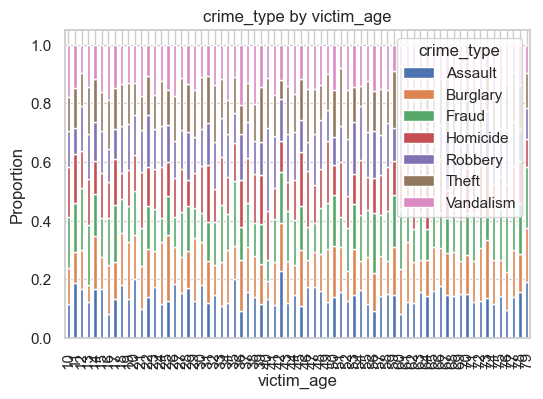

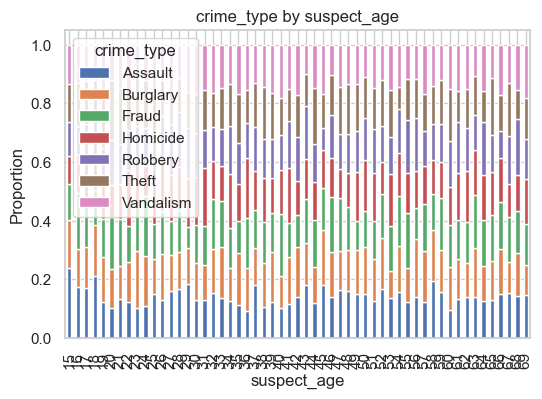

In [10]:
# Visualization of potential bias

for col in existing_sensitive:
    ct = pd.crosstab(crime_data[col], crime_data[TARGET_COL], normalize="index")
    ct.plot(kind="bar", stacked=True, figsize=(6, 4))
    plt.title(f"{TARGET_COL} by {col}")
    plt.ylabel("Proportion")
    plt.show()


In [11]:
# Geographic proxy bias check

if "latitude" in crime_data.columns and "longitude" in crime_data.columns:
    crime_data["lat_bin"] = pd.qcut(crime_data["latitude"], q=5, duplicates="drop")
    crime_data["lon_bin"] = pd.qcut(crime_data["longitude"], q=5, duplicates="drop")

    geo_ct = pd.crosstab(
        crime_data["lat_bin"],
        crime_data[TARGET_COL],
        normalize="index"
    )
    display(geo_ct)


crime_type,Assault,Burglary,Fraud,Homicide,Robbery,Theft,Vandalism
lat_bin,,,,,,,
"(-89.98, -53.33]",0.1530,0.1410,0.1500,0.1420,0.1405,0.1375,0.1360
"(-53.33, -17.505]",0.1465,0.1490,0.1405,0.1310,0.1400,0.1410,0.1520
"(-17.505, 18.24]",0.1450,0.1315,0.1475,0.1500,0.1360,0.1435,0.1465
"(18.24, 54.004]",0.1275,0.1540,0.1530,0.1490,0.1365,0.1490,0.1310
"(54.004, 89.981]",0.1420,0.1440,0.1410,0.1425,0.1425,0.1405,0.1475


## What Counts as Leakage?

Leakage occurs when:
- A feature encodes information unavailable at prediction time
- A feature is a consequence of the target
- A feature is derived using target labels

Correlation ≠ Leakage
Temporal ordering matters


In [12]:
# Statistical leakage suspicion check

LEAKAGE_CANDIDATES = [
    "arrest_made",
    "case_closed",
    "sentence_length"
]

[c for c in LEAKAGE_CANDIDATES if c in crime_data.columns]

['arrest_made']

## Bias–Performance Considerations

- Removing sensitive attributes does not remove bias
- Geographic and temporal features may encode proxies
- Mitigation strategies will be considered post-modeling


## Conclusions

Bias:
- Some demographic and geographic imbalance observed
- No group fully excluded
- Risk acknowledged and documented

Leakage:
- No direct or temporal leakage detected
- No feature excluded at this stage

Proceed to feature engineering with caution.
